In [233]:
import pandas as pd

# 读取从Kaggle下载的房价数据集
data = pd.read_csv("housing.csv")


In [234]:
# 输出数据集维度，20640行表示20640个样本，10个属性
print(data.shape)

(20640, 10)


In [235]:
# columns输出数据集的列
# 这里每一列的意思依次是：经度，纬度，房龄中位数，总房间数量，总卧室数量，人口数量，家庭户数，收入中位数，房价中位数(y)，距海种类（近海/内陆/海岛）
# 预测就是用其他特征预测房价中位数
print(data.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [236]:
# 表格里面是非空值数量+数据类型
# 注意total_bedrooms有空值，因为非空值只有20433个
# 注意ocean_proximity是object类型，非数值列
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [237]:
# 数据预处理阶段，我们首先处理oceam_proximity属性，因为他是字符型数据，可以把他变成独热编码处理，首先查看它的取值情况
# value_counts()函数就是读取这一列然后统计取值，一共五种取值，发现ISLAND只有5种取值情况
print(data["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [238]:
# 这一步就是把上面的字符转变成5列的独热编码，只有自己的取值那一列为1，其他为0
# 函数的参数是选择oceam_proximity这一列，新的列名前缀为ocean，所以列名就是ocean+取值，然后值的类型是0/1的int类型
data_1hot = pd.get_dummies(data, columns=["ocean_proximity"], prefix="ocean", dtype=int)

In [239]:
# 原先10列，现在删掉一列多了5列，总共14列
print(data_1hot.shape)

(20640, 14)


In [240]:
print(data_1hot.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND',
       'ocean_NEAR BAY', 'ocean_NEAR OCEAN'],
      dtype='object')


In [241]:
# 现在还有缺失值没处理
print(data_1hot.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_<1H OCEAN     20640 non-null  int64  
 10  ocean_INLAND        20640 non-null  int64  
 11  ocean_ISLAND        20640 non-null  int64  
 12  ocean_NEAR BAY      20640 non-null  int64  
 13  ocean_NEAR OCEAN    20640 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 2.2 MB
None


In [242]:
# 计算缺失值的数量
missing_count = 20640 - 20433
missing_ratio = missing_count / 20640 * 100
print(f"缺失值数量：{missing_count}")
print(f"缺失比例：{missing_ratio:.16f}%")

缺失值数量：207
缺失比例：1.0029069767441861%


In [243]:
# 考虑到缺失值很小，只占数据集的1%，所以我们直接删去有缺失值的列
# dropna()就是删除的函数，axis=0表示按第一个维度，或者说行维度删，subset选定删除total_bedrooms为空的行
data_1hot_clean = data_1hot.dropna(axis=0, subset=["total_bedrooms"])

In [244]:
# 还差最后一步，就是把目标变量放到最后，其他的放前面
print(data_1hot_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_<1H OCEAN     20433 non-null  int64  
 10  ocean_INLAND        20433 non-null  int64  
 11  ocean_ISLAND        20433 non-null  int64  
 12  ocean_NEAR BAY      20433 non-null  int64  
 13  ocean_NEAR OCEAN    20433 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 2.3 MB
None


In [245]:
# 首先，取出目标变量y
y_column = data_1hot_clean["median_house_value"]

# 剩下的变量全部是X，所以按照第二个维度也就是列维度，丢掉drop目标变量y
X_features = data_1hot_clean.drop("median_house_value", axis=1)

# 然后把两个按照第二个维度列维度进行concat拼接
data_final = pd.concat([X_features, y_column], axis=1)

In [246]:
print(data_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   ocean_<1H OCEAN     20433 non-null  int64  
 9   ocean_INLAND        20433 non-null  int64  
 10  ocean_ISLAND        20433 non-null  int64  
 11  ocean_NEAR BAY      20433 non-null  int64  
 12  ocean_NEAR OCEAN    20433 non-null  int64  
 13  median_house_value  20433 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 2.3 MB
None


In [247]:
# 分析特征与房价的相关性
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 使用 data_final（未归一化的数据）
corr_matrix = data_final.corr()

# 提取各特征与房价的相关性，并排序
correlation_with_price = corr_matrix['median_house_value'].sort_values(ascending=False)

print("各特征与房价的相关性：")
print(correlation_with_price)

各特征与房价的相关性：
median_house_value    1.000000
median_income         0.688355
ocean_<1H OCEAN       0.257614
ocean_NEAR BAY        0.160526
ocean_NEAR OCEAN      0.140378
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
ocean_ISLAND          0.023525
population           -0.025300
longitude            -0.045398
latitude             -0.144638
ocean_INLAND         -0.484787
Name: median_house_value, dtype: float64


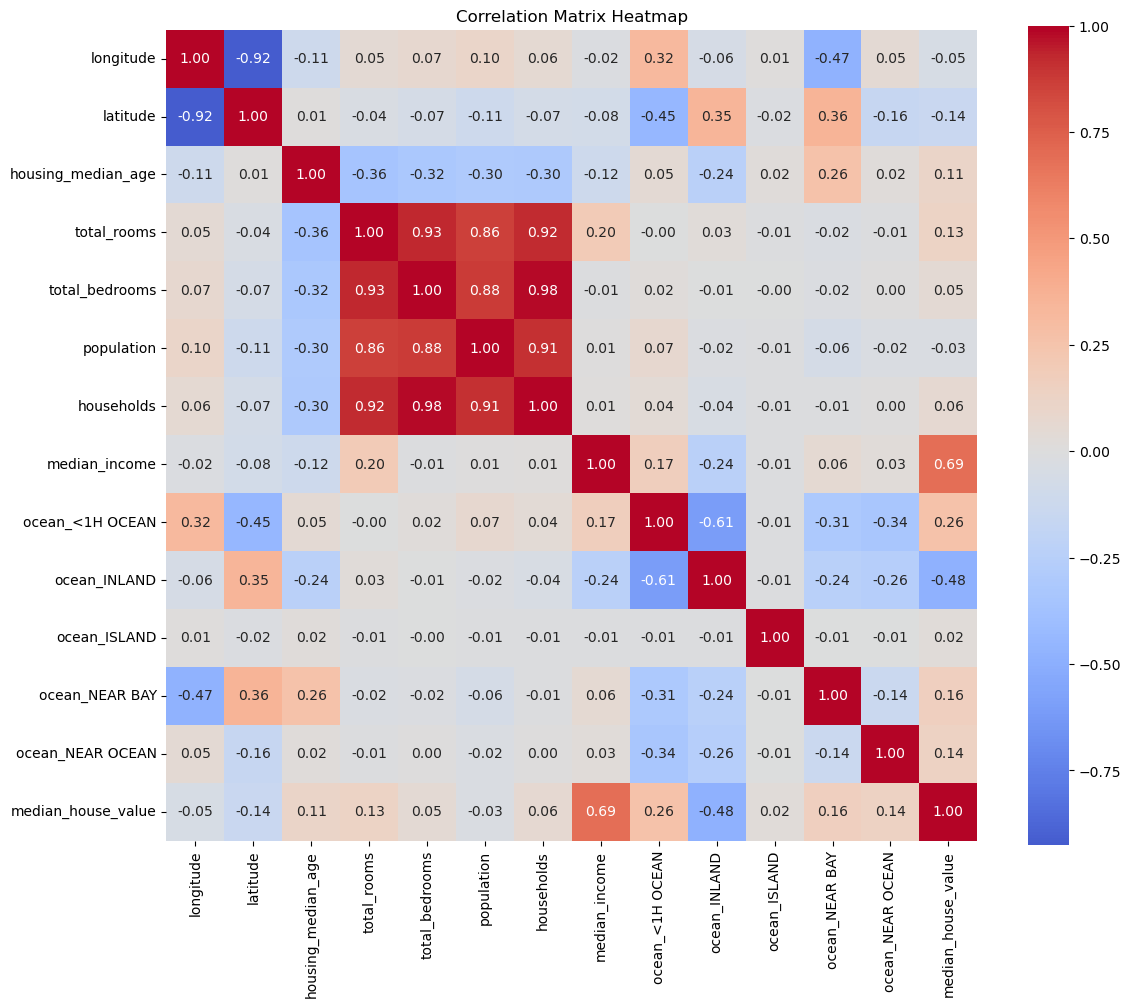

In [248]:
# 绘制热力图
plt.figure(figsize=(12, 10))

# 绘制相关系数矩阵热力图
sns.heatmap(corr_matrix, 
            annot=True,           # 显示数值
            fmt='.2f',            # 保留2位小数
            cmap='coolwarm',      # 颜色：红=正相关，蓝=负相关
            center=0,             # 以0为中心
            square=True)          # 正方形格子

plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [249]:
# 划分测试集和训练集，调用sklearn的API
from sklearn.model_selection import train_test_split

# 参数是数据集，测试集的大小和固定划分的随机种子
train_data, test_data = train_test_split(
    data_final,
    test_size = 0.3,
    random_state = 10
)

In [250]:
# 训练集，占原始数据的70%
print(train_data.shape)

(14303, 14)


In [251]:
# 测试集，占原始数据的30%
print(test_data.shape)

(6130, 14)


In [252]:
# 下一步是分离训练集和测试集的特征矩阵X和目标向量y
# 线性回归模型的公式是：y = θX
n = train_data.shape[1] # 获取总列数，14

# 意思是取所有的行，第0列到第12列作为X，也就是特征
# 注意总列数14列但是其实是0-13列的下标
X = train_data.iloc[:, 0:n-1]
# 这里要把y变成(14303,1)的格式，否则矩阵乘法会出错
y = train_data.iloc[:, n-1:n]

# 测试集同理
X_test = test_data.iloc[:, 0:n-1]
y_test = test_data.iloc[:, n-1:n]

In [253]:
print(f"X形状：{X.shape}, y形状：{y.shape}")
print(f"X_test形状：{X_test.shape}, y_test形状：{y_test.shape}")

X形状：(14303, 13), y形状：(14303, 1)
X_test形状：(6130, 13), y_test形状：(6130, 1)


In [254]:
# 现在还是pandas的类型，所以把他转变成numpy的矩阵
import numpy as np

X = np.matrix(X.values)
y = np.matrix(y.values)

X_test = np.matrix(X_test.values)
y_test = np.matrix(y_test.values)

In [255]:
# X类型：<class 'numpy.matrix'>, X形状：(14303, 13), y类型：<class 'numpy.matrix'>, y形状：(14303, 1)
print(f"X类型：{type(X)}, X形状：{X.shape}, y类型：{type(y)}, y形状：{y.shape}")
# X_test类型：<class 'numpy.matrix'>, X_test形状：(6130, 13), y_test类型：<class 'numpy.matrix'>, y_test形状：(6130, 1)
print(f"X_test类型：{type(X_test)}, X_test形状：{X_test.shape}, y_test类型：{type(y_test)}, y_test形状：{y_test.shape}")

X类型：<class 'numpy.matrix'>, X形状：(14303, 13), y类型：<class 'numpy.matrix'>, y形状：(14303, 1)
X_test类型：<class 'numpy.matrix'>, X_test形状：(6130, 13), y_test类型：<class 'numpy.matrix'>, y_test形状：(6130, 1)


In [256]:
# 通过查看数据文件，现在的特征里面特征的尺度大小很大，因此需要进行标准化
# 采用Z得分标准化，也就是每一个特征的每一个数据，减去这个特征的均值再除以标准差
def norm(X, miu=None, sigma=None):
    """
    标准化：减去均值，除以标准差
    axis=0表示沿着行消灭维度，也就是对于每一个特征列计算它的均值和标准差
    把axis理解为按某个维度走消灭维度就好
    """
    if miu is None:
        sigma = np.std(X, axis=0)
        miu = np.mean(X, axis=0)
    return (X - miu) / sigma, miu, sigma

In [257]:
# 把训练集和测试集都进行标准化 注意测试集也是用训练集的标准差和均值，因为实际中你不应该知道测试集的数据
X_scaled, miu, sigma = norm(X)

X_test_scaled, _, _, = norm(X_test, miu, sigma)

In [258]:
# 下一步是添加偏置项，也就是线性回归的截距，方法是把X和X_test都加入一个元素全为1的列，后续学习的参数的维度就是(14,1)，多出来的一个就是截距b
# y = θ_0 * 1 + θ_1 * x_1 + θ_2 * x_2 + ... + θ_n * x_n = θ * X
# np.c_表示按列column拼接，里面生成一个维度为y.size的全1数组作为偏置项
# size是元素总数，是一个标量；shape是维度形状，是一个元组
# np.c_自动把按size生成的一维数组转变成列向量拼接
X_scaled = np.c_[np.ones(y.size), X_scaled]
X_test_scaled = np.c_[np.ones(y_test.size), X_test_scaled]

In [259]:
# 现在相当于每个数据集的维度多了一个偏置项，里面的特征的数值都进行了归一化
# 学习的参数θ的维度是(14,1)

# X类型：<class 'numpy.matrix'>, X形状：(14303, 14), y类型：<class 'numpy.matrix'>, y形状：(14303, 1)
print(f"X类型：{type(X_scaled)}, X形状：{X_scaled.shape}, y类型：{type(y)}, y形状：{y.shape}")
# X_test类型：<class 'numpy.matrix'>, X_test形状：(6130, 14), y_test类型：<class 'numpy.matrix'>, y_test形状：(6130, 1)
print(f"X_test类型：{type(X_test_scaled)}, X_test形状：{X_test_scaled.shape}, y_test类型：{type(y_test)}, y_test形状：{y_test.shape}")

X类型：<class 'numpy.matrix'>, X形状：(14303, 14), y类型：<class 'numpy.matrix'>, y形状：(14303, 1)
X_test类型：<class 'numpy.matrix'>, X_test形状：(6130, 14), y_test类型：<class 'numpy.matrix'>, y_test形状：(6130, 1)


In [260]:
# 现在开始用梯度下降求解参数θ
# 初始化BGD的参数θ，维度为(14,1)
theta_bgd = np.matrix(np.zeros(14)).T

# BGD超参数
alpha_bgd = 0.005           # BGD学习率可以较大
num_iterations_bgd = 20000  # BGD迭代次数

# BGD每一轮的损失值，用来画图用
J_history_bgd = np.zeros(num_iterations_bgd)

# 初始化SGD的参数θ，维度为(14,1)，必须独立初始化不能复用BGD的
theta_sgd = np.matrix(np.zeros(14)).T

# SGD超参数
alpha_sgd = 0.0001      # SGD学习率通常比BGD小很多
num_epochs_sgd = 50     # SGD的epoch数（遍历整个数据集的次数）
# 注意：SGD每个epoch内会遍历所有样本一次，所以总更新次数 = num_epochs_sgd * m

# SGD每一轮的损失值，用来画图用
J_history_sgd = np.zeros(num_epochs_sgd)

# 初始化Mini-Batch GD的参数θ，维度为(14,1)
theta_mbgd = np.matrix(np.zeros(14)).T

# Mini-Batch GD超参数
alpha_mbgd = 0.001          # 学习率介于BGD和SGD之间
batch_size = 32             # 每个batch的样本数
num_epochs_mbgd = 50        # epoch数

# Mini-Batch GD每一轮的损失值，用来画图用
J_history_mbgd = np.zeros(num_epochs_mbgd)
# 初始化Mini-Batch Momentum的参数θ，维度为(14,1)
theta_momentum = np.matrix(np.zeros(14)).T

# Mini-Batch Momentum超参数
alpha_momentum = 0.001      # 学习率
beta = 0.9                  # 动量系数，通常取0.8-0.99
num_epochs_momentum = 50    # epoch数

# Mini-Batch Momentum每一轮的损失值，用来画图用
J_history_momentum = np.zeros(num_epochs_momentum)

In [261]:
# 定义损失函数
def cost(theta, X, y):
    """
    计算损失函数均方误差
    X:(m, n), y:(m, 1), theta:(n, 1)
    """
    m = y.size  # 总样本数量
    predictions = X @ theta  # 预测值，@表示矩阵乘法
    errors = predictions - y  # 误差
    return np.sum(np.power(errors, 2)) / (2 * m)    # 返回MSE，误差的平方/2M，分母的2是求导方便 

In [262]:
# 定义梯度下降，注意这里是批量，也就是每次都拿全量样本更新参数
def gradient_descent(theta, alpha, num_iters, X, y):
    """
    批量梯度下降
    """
    m = y.size
    J_history = np.zeros(num_iters)

    for i in range(num_iters):
        J_history[i] = cost(theta, X, y)

        # 这个是公式推导出来的结论
        gradients = (X.T @ (X @ theta - y)) / m

        theta = theta - alpha * gradients

    return theta, J_history

In [263]:
# 定义随机梯度下降SGD
def stochastic_gradient_descent(theta, alpha, num_epochs, X, y):
    """
    随机梯度下降 (Stochastic Gradient Descent, SGD)
    每次只使用一个随机样本来计算梯度并更新参数
    """
    m = y.size  # 样本总数
    n = theta.size  # 特征维度（包含偏置项）
    J_history = np.zeros(num_epochs)
    
    for epoch in range(num_epochs):
        # 随机打乱样本顺序，保证每个epoch遍历顺序不同
        # permutation生成0到m-1的随机排列
        indices = np.random.permutation(m)
        
        # 遍历每一个样本
        for i in indices:
            # 取出第i个样本，注意X是matrix类型，需要用切片取行
            x_i = X[i, :]  # 形状 (1, n)
            y_i = y[i, 0]  # 标量
            
            # 计算单个样本的预测值 (1, n) @ (n, 1) = (1, 1)
            prediction = x_i @ theta
            
            # 计算单个样本的误差
            error = prediction - y_i
            
            # 计算梯度：对于单个样本，梯度 = x_i^T * error
            # x_i.T 形状 (n, 1)，error 是标量，结果 (n, 1)
            gradient = x_i.T * error
            
            # 更新参数
            theta = theta - alpha * gradient
        
        # 记录当前epoch结束后的平均损失（用全部样本计算）
        J_history[epoch] = cost(theta, X, y)
    
    return theta, J_history

In [264]:
# 定义小批量梯度下降Mini-Batch GD
def mini_batch_gradient_descent(theta, alpha, num_epochs, batch_size, X, y):
    """
    小批量梯度下降 (Mini-Batch Gradient Descent)
    每次使用一小批样本来计算梯度并更新参数，是BGD和SGD的折中
    """
    m = y.size  # 样本总数
    n = theta.size  # 特征维度
    J_history = np.zeros(num_epochs)
    
    # 计算每个epoch有多少个batch
    num_batches = m // batch_size  # 整除
    
    for epoch in range(num_epochs):
        # 随机打乱样本顺序
        indices = np.random.permutation(m)
        
        # 按batch遍历
        for b in range(num_batches):
            # 取出当前batch的样本索引
            batch_indices = indices[b * batch_size : (b + 1) * batch_size]
            
            # 取出batch数据
            X_batch = X[batch_indices, :]  # 形状 (batch_size, n)
            y_batch = y[batch_indices, :]  # 形状 (batch_size, 1)
            
            # 计算batch的梯度
            # 注意这里除以batch_size而不是m，因为是对batch求平均
            gradients = (X_batch.T @ (X_batch @ theta - y_batch)) / batch_size
            
            # 更新参数
            theta = theta - alpha * gradients
        
        # 记录当前epoch的平均损失
        J_history[epoch] = cost(theta, X, y)
    
    return theta, J_history

In [265]:
# 定义带动量的Mini-Batch梯度下降Momentum
def mini_batch_momentum(theta, alpha, beta, num_epochs, batch_size, X, y):
    """
    Mini-Batch Momentum梯度下降
    使用动量加速收敛，减少震荡
    """
    m = y.size
    n = theta.size
    J_history = np.zeros(num_epochs)
    
    # 初始化速度项v为零向量
    v = np.matrix(np.zeros(n)).T
    
    num_batches = m // batch_size
    
    for epoch in range(num_epochs):
        indices = np.random.permutation(m)
        
        for b in range(num_batches):
            batch_indices = indices[b * batch_size : (b + 1) * batch_size]
            
            X_batch = X[batch_indices, :]
            y_batch = y[batch_indices, :]
            
            # 计算batch梯度
            gradients = (X_batch.T @ (X_batch @ theta - y_batch)) / batch_size
            
            # 更新速度项：v = beta * v + (1 - beta) * gradients
            v = beta * v + (1 - beta) * gradients
            
            # 更新参数
            theta = theta - alpha * v
        
        J_history[epoch] = cost(theta, X, y)
    
    return theta, J_history

In [266]:
# 现在开始执行三种梯度下降算法，注意要用训练集
theta_bgd, J_history_bgd = gradient_descent(theta_bgd, alpha_bgd, num_iterations_bgd, X_scaled, y)

theta_sgd, J_history_sgd = stochastic_gradient_descent(theta_sgd, alpha_sgd, num_epochs_sgd, X_scaled, y)

theta_mbgd, J_history_mbgd = mini_batch_gradient_descent(theta_mbgd, alpha_mbgd, num_epochs_mbgd, batch_size, X_scaled, y)

# 执行Mini-Batch Momentum训练
theta_momentum, J_history_momentum = mini_batch_momentum(theta_momentum, alpha_momentum, beta, num_epochs_momentum, batch_size, X_scaled, y)

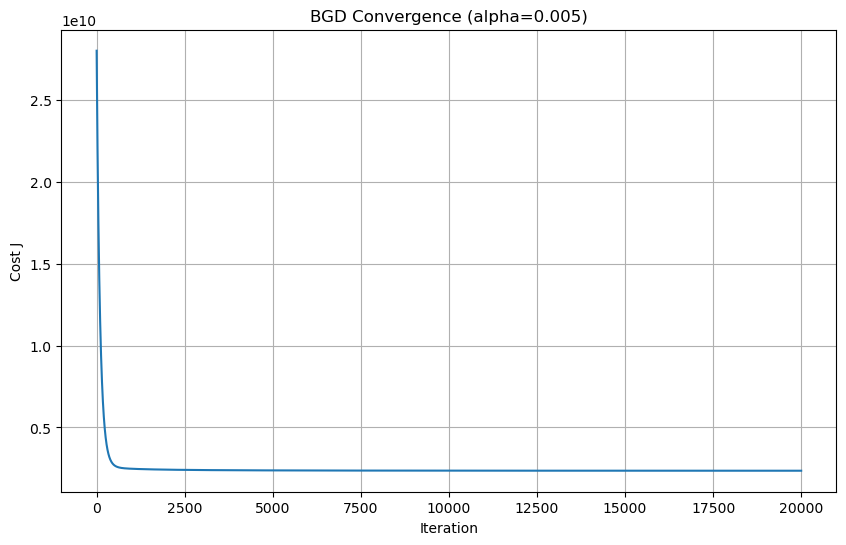

BGD 最终损失: 2351094365.659074


In [267]:
# 可视化BGD训练过程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(J_history_bgd)
plt.xlabel('Iteration')
plt.ylabel('Cost J')
plt.title(f'BGD Convergence (alpha={alpha_bgd})')
plt.grid(True)
plt.show()

print(f"BGD 最终损失: {J_history_bgd[-1]:.6f}")

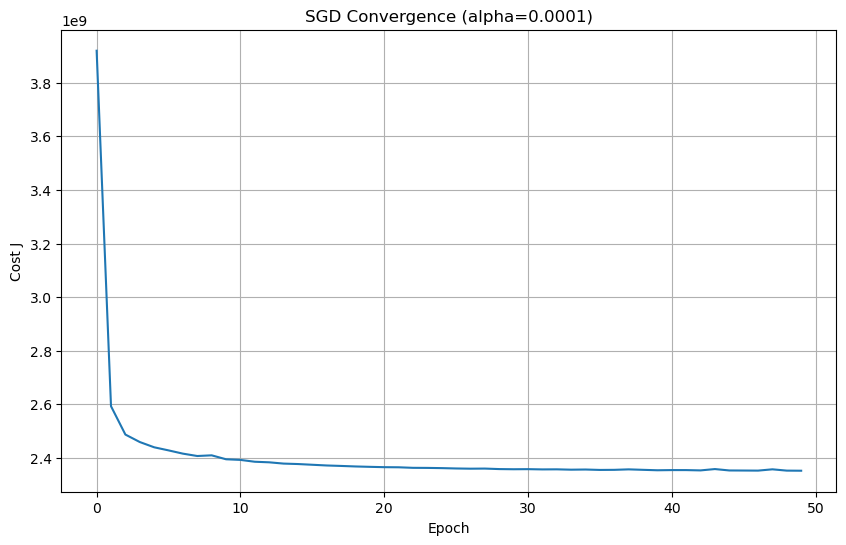

SGD 最终损失: 2352527545.910707


In [268]:
# 可视化SGD训练过程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(J_history_sgd)
plt.xlabel('Epoch')
plt.ylabel('Cost J')
plt.title(f'SGD Convergence (alpha={alpha_sgd})')
plt.grid(True)
plt.show()

print(f"SGD 最终损失: {J_history_sgd[-1]:.6f}")

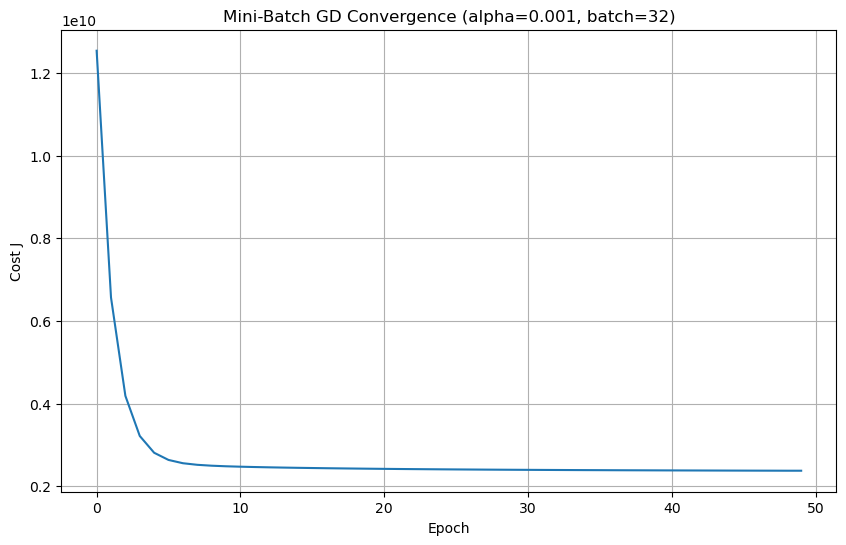

Mini-Batch GD 最终损失: 2375120218.070711


In [269]:
# 可视化Mini-Batch GD训练过程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(J_history_mbgd)
plt.xlabel('Epoch')
plt.ylabel('Cost J')
plt.title(f'Mini-Batch GD Convergence (alpha={alpha_mbgd}, batch={batch_size})')
plt.grid(True)
plt.show()

print(f"Mini-Batch GD 最终损失: {J_history_mbgd[-1]:.6f}")

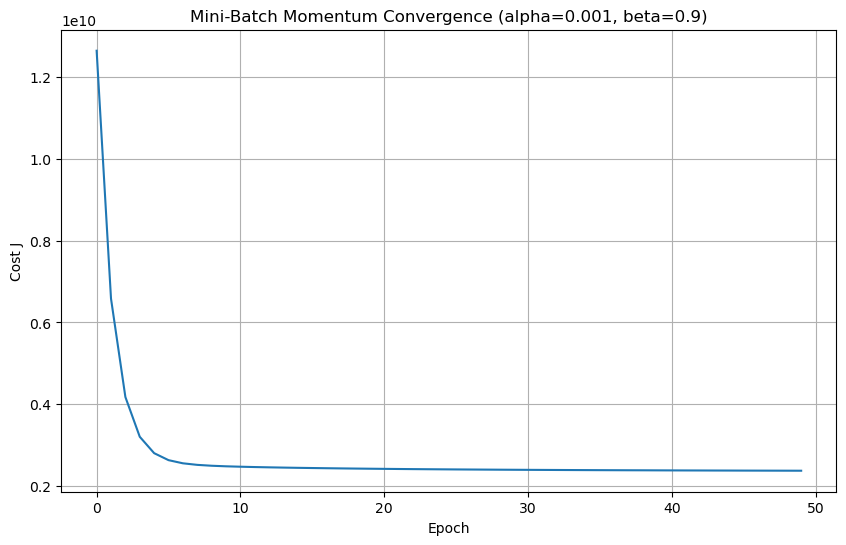

Mini-Batch Momentum最终损失: 2374710669.381153


In [270]:
# 可视化Mini-Batch Momentum训练过程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(J_history_momentum)
plt.xlabel('Epoch')
plt.ylabel('Cost J')
plt.title(f'Mini-Batch Momentum Convergence (alpha={alpha_momentum}, beta={beta})')
plt.grid(True)
plt.show()

print(f"Mini-Batch Momentum最终损失: {J_history_momentum[-1]:.6f}")

In [271]:
# 训练之后，也就是得到了学习出的参数θ，接下来用R^2决定系数来平均模型的好坏
# 决定系数为1，表示完美预测，为0表示和直接猜均值一样差，小于0表示比猜均值还差
def r2_score(X, y, theta):
    y_pred = X @ theta
    y_mean = np.mean(y)

    sse = np.sum(np.power(y - y_pred, 2))

    sst = np.sum(np.power(y - y_mean, 2))

    r2 = 1 - (sse / sst)

    return r2

In [272]:
# 计算三种算法的R²决定系数
r2_train_bgd = r2_score(X_scaled, y, theta_bgd)
r2_test_bgd = r2_score(X_test_scaled, y_test, theta_bgd)

r2_train_sgd = r2_score(X_scaled, y, theta_sgd)
r2_test_sgd = r2_score(X_test_scaled, y_test, theta_sgd)

r2_train_mbgd = r2_score(X_scaled, y, theta_mbgd)
r2_test_mbgd = r2_score(X_test_scaled, y_test, theta_mbgd)

# 计算Momentum的R²
r2_train_momentum = r2_score(X_scaled, y, theta_momentum)
r2_test_momentum = r2_score(X_test_scaled, y_test, theta_momentum)

In [273]:
# 打印四种算法的R²对比
print("=" * 70)
print("四种梯度下降算法R²对比:")
print("=" * 70)
print(f"BGD:          训练集 R² = {r2_train_bgd:.16f}, 测试集 R² = {r2_test_bgd:.16f}")
print(f"SGD:          训练集 R² = {r2_train_sgd:.16f}, 测试集 R² = {r2_test_sgd:.16f}")
print(f"Mini-Batch:   训练集 R² = {r2_train_mbgd:.16f}, 测试集 R² = {r2_test_mbgd:.16f}")
print(f"Momentum:     训练集 R² = {r2_train_momentum:.16f}, 测试集 R² = {r2_test_momentum:.16f}")
print("=" * 70)

四种梯度下降算法R²对比:
BGD:          训练集 R² = 0.6482943184925447, 测试集 R² = 0.6411221522751479
SGD:          训练集 R² = 0.6480799095328630, 测试集 R² = 0.6407895005022957
Mini-Batch:   训练集 R² = 0.6447002189340161, 测试集 R² = 0.6359103491880091
Momentum:     训练集 R² = 0.6447614842790832, 测试集 R² = 0.6357034667578719


In [274]:
# 梯度下降需要训练多轮，从而不断更新得到参数θ，我们可以用正规方程直接得到θ
# 公式：theta = (X^T X)^(-1) * X^T * y
# 显然前面的就是调用np的线性代数库求矩阵的逆
theta_normal = np.linalg.inv(X_scaled.T @ X_scaled) @ X_scaled.T @ y

In [275]:
# 计算正规方程的 R^2
r2_train_normal = r2_score(X_scaled, y, theta_normal)
r2_test_normal = r2_score(X_test_scaled, y_test, theta_normal)

In [276]:
# 得到接近的结果是正确的，因为两者都是在优化同一个目标，梯度下降收敛，并且线性回归的损失函数是凸的只有一个最优解
print(f"正规方程训练集 R²: {r2_train_normal:.16f}")
print(f"正规方程测试集 R²: {r2_test_normal:.16f}")

正规方程训练集 R²: 0.6483732418285790
正规方程测试集 R²: 0.6412797515712161
